## Task 1 - 4 Marks

Load the Oxford-IIIT Pets dataset from Torchvision datasets (both train and test partition).

Randomly shuffle the train partition and split the train partition further into training and validation
sets (80% training, 20% validation).

Show the class distribution on the training partition.

Define transform to resize the images to size 224 x 224. Define Dataloaders for training,
validation, and test sets that use this transform.

In [1]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

In [2]:
train_val_dataset = datasets.OxfordIIITPet(root='./data', split='trainval', download=True)
test_dataset = datasets.OxfordIIITPet(root='./data', split='test', download=True)

train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size

train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

print(f"Original train/val dataset size: {len(train_val_dataset)}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Original train/val dataset size: 3680
Training dataset size: 2944
Validation dataset size: 736
Test dataset size: 3669


Class distribution on the training partition:
Class 0: 82 samples
Class 1: 78 samples
Class 2: 83 samples
Class 3: 87 samples
Class 4: 85 samples
Class 5: 79 samples
Class 6: 86 samples
Class 7: 80 samples
Class 8: 78 samples
Class 9: 80 samples
Class 10: 77 samples
Class 11: 70 samples
Class 12: 77 samples
Class 13: 85 samples
Class 14: 84 samples
Class 15: 84 samples
Class 16: 82 samples
Class 17: 71 samples
Class 18: 75 samples
Class 19: 75 samples
Class 20: 76 samples
Class 21: 84 samples
Class 22: 73 samples
Class 23: 81 samples
Class 24: 83 samples
Class 25: 81 samples
Class 26: 77 samples
Class 27: 78 samples
Class 28: 78 samples
Class 29: 77 samples
Class 30: 79 samples
Class 31: 81 samples
Class 32: 81 samples
Class 33: 78 samples
Class 34: 76 samples
Class 35: 80 samples
Class 36: 83 samples


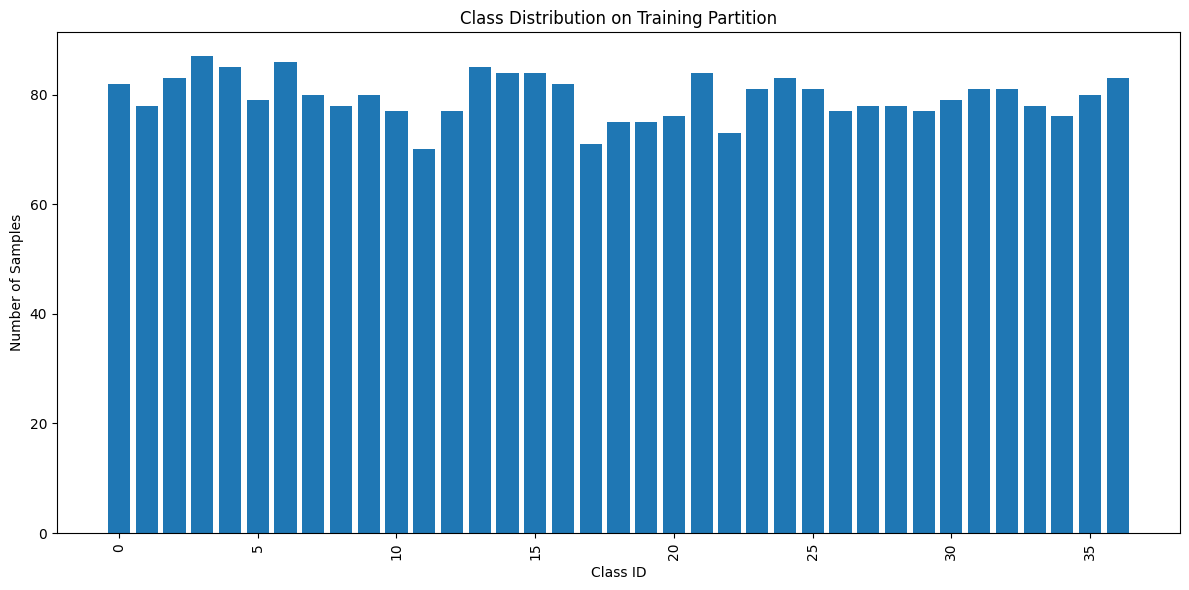

In [3]:
import matplotlib.pyplot as plt

cls_counts = {}
for _, target in train_dataset:
    if target not in cls_counts:
        cls_counts[target] = 0
    cls_counts[target] += 1
sorted_class_counts = dict(sorted(cls_counts.items()))
print("Class distribution on the training partition:")
for cls_id, count in sorted_class_counts.items():
    print(f"Class {cls_id}: {count} samples")

plt.figure(figsize=(12, 6))
plt.bar(list(sorted_class_counts.keys()), list(sorted_class_counts.values()))
plt.xlabel("Class ID")
plt.ylabel("Number of Samples")
plt.title("Class Distribution on Training Partition")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [5]:
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_val_dataset_transformed = datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform)
test_dataset_transformed = datasets.OxfordIIITPet(root='./data', split='test', download=True, transform=transform)

train_size = int(0.8 * len(train_val_dataset_transformed))
val_size = len(train_val_dataset_transformed) - train_size

train_dataset_transformed, val_dataset_transformed = random_split(train_val_dataset_transformed, [train_size, val_size], generator=torch.Generator().manual_seed(42))
train_dataloader = DataLoader(train_dataset_transformed, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset_transformed, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset_transformed, batch_size=batch_size, shuffle=False)

## Task 2 - 4 Marks

Load the pretrained ResNet-18 model with the default weights (trained on ImageNet)

Extract the features after the GAP layer of the ResNet-18 model. Replace the final FC layer of
the model with one or more 1x1 convolutional layers, where the number of 1x1 convolutional
filters in the last layer should be the number of classes of this dataset.

In [6]:
import torchvision.models as models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print("Pre-trained ResNet-18 model loaded successfully.")
print(model)

Pre-trained ResNet-18 model loaded successfully.
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [7]:
import torch.nn as nn

num_classes = len(sorted_class_counts)

class CustomResNet18(nn.Module):
    def __init__(self, num_classes):
        super(CustomResNet18, self).__init__()
        resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(
            resnet18.conv1,
            resnet18.bn1,
            resnet18.relu,
            resnet18.maxpool,
            resnet18.layer1,
            resnet18.layer2,
            resnet18.layer3,
            resnet18.layer4,
            resnet18.avgpool
        )

        self.classifier = nn.Conv2d(512, num_classes, kernel_size=1)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        x = x.flatten(1)
        return x

model = CustomResNet18(num_classes=num_classes)

print("Custom ResNet-18 model with 1x1 conv layer created successfully.")
print(model)

Custom ResNet-18 model with 1x1 conv layer created successfully.
CustomResNet18(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchN

## Task 3 - 2 Marks

Train the model using SGD and a suitable learning rate.


In [26]:
epochs = 30
learning_rate = 0.001

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [10]:
train_losses = []
val_losses = []
model=model.to(device)
for epoch in range(epochs):
    model.train()
    curr_loss = 0.0
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        curr_loss += loss.item()
    train_losses.append(curr_loss / len(train_dataloader))

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_dataloader))

    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}")

Epoch 1/30, Training Loss: 3.5495, Validation Loss: 3.3685
Epoch 2/30, Training Loss: 3.1711, Validation Loss: 3.0309
Epoch 3/30, Training Loss: 2.8436, Validation Loss: 2.7204
Epoch 4/30, Training Loss: 2.5384, Validation Loss: 2.4300
Epoch 5/30, Training Loss: 2.2534, Validation Loss: 2.1625
Epoch 6/30, Training Loss: 2.0119, Validation Loss: 1.9342
Epoch 7/30, Training Loss: 1.7903, Validation Loss: 1.7209
Epoch 8/30, Training Loss: 1.6154, Validation Loss: 1.5671
Epoch 9/30, Training Loss: 1.4449, Validation Loss: 1.4143
Epoch 10/30, Training Loss: 1.3082, Validation Loss: 1.2994
Epoch 11/30, Training Loss: 1.2033, Validation Loss: 1.1919
Epoch 12/30, Training Loss: 1.0991, Validation Loss: 1.1002
Epoch 13/30, Training Loss: 1.0117, Validation Loss: 1.0277
Epoch 14/30, Training Loss: 0.9396, Validation Loss: 0.9681
Epoch 15/30, Training Loss: 0.8718, Validation Loss: 0.9123
Epoch 16/30, Training Loss: 0.8106, Validation Loss: 0.8581
Epoch 17/30, Training Loss: 0.7583, Validation Lo

## Task 4 - 1 Mark

Show the training and validation losses as a function of the number of epochs.


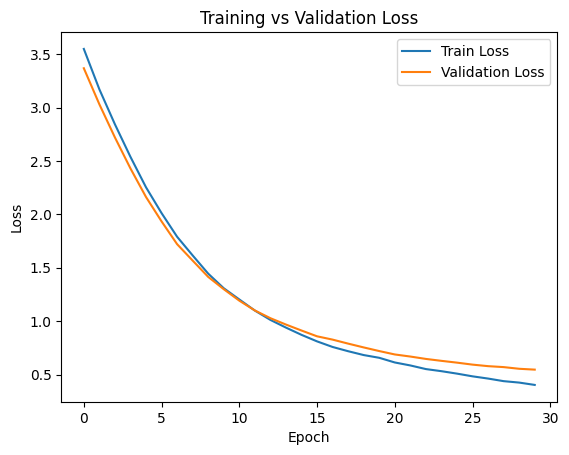

In [11]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

## Task 4 - 2 Marks

Report the classification performance on the test partition of the dataset. Show the confusion
matrix, accuracy, and F1 score.

Accuracy: 0.8697192695557373
F1 Score: 0.8670596327565799


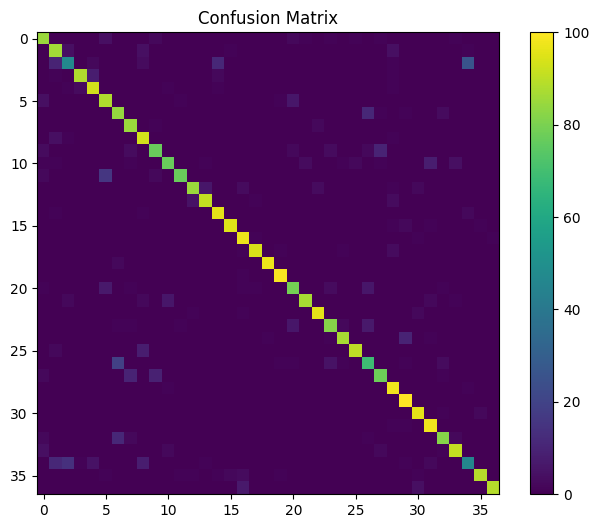

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import numpy as np

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cfn_matrix = confusion_matrix(all_labels, all_preds)
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average="macro")
print("Accuracy:", acc)
print("F1 Score:", f1)
plt.figure(figsize=(8, 6))
plt.imshow(cfn_matrix)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

## Task 5 - 3 Marks

Use Grad-CAM to visualize the class activation maps on a few test images (randomly sample
5). You can use the torchcam library for this question

In [13]:
get_ipython().system('pip install torchcam')
print("Installed torchcam library.")

Installed torchcam library.


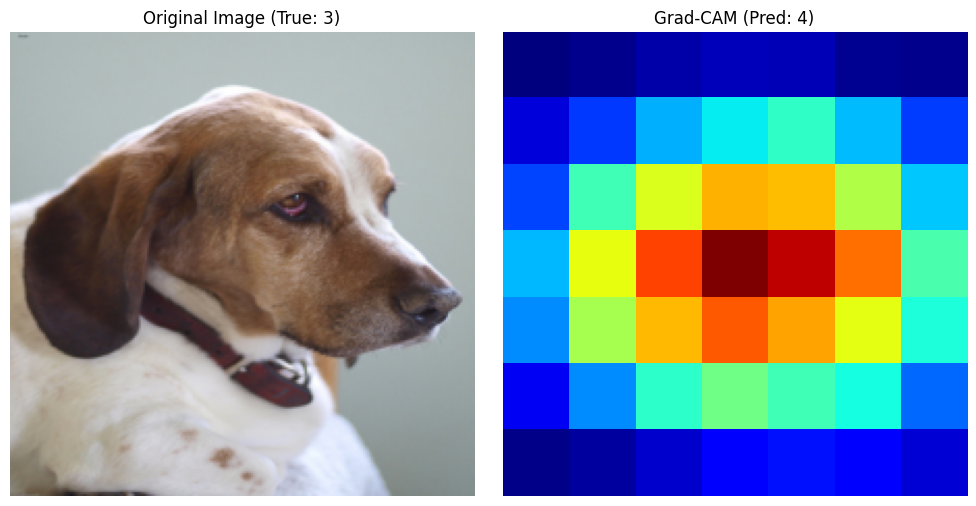

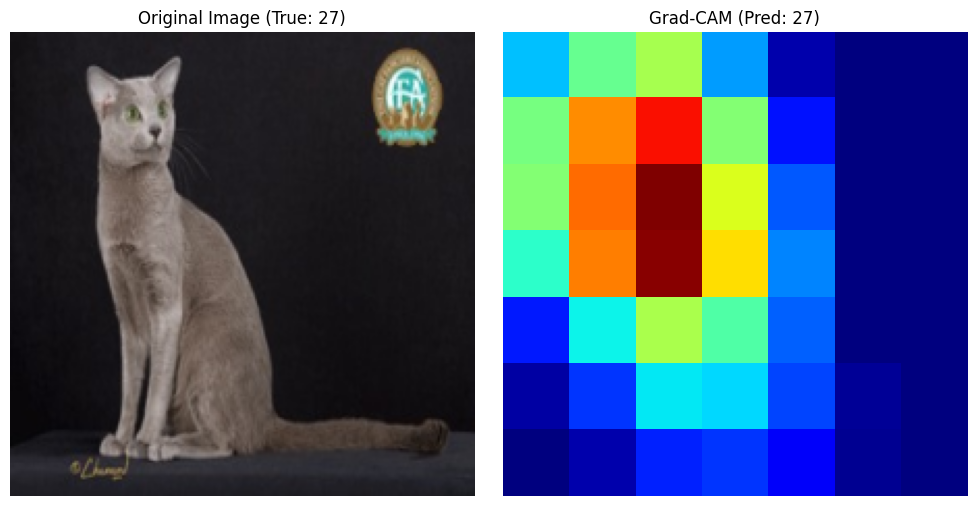

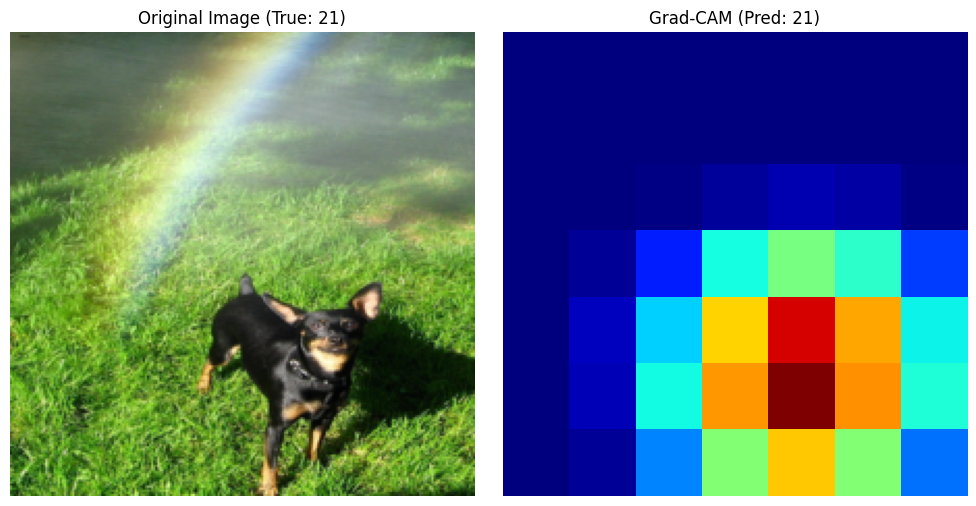

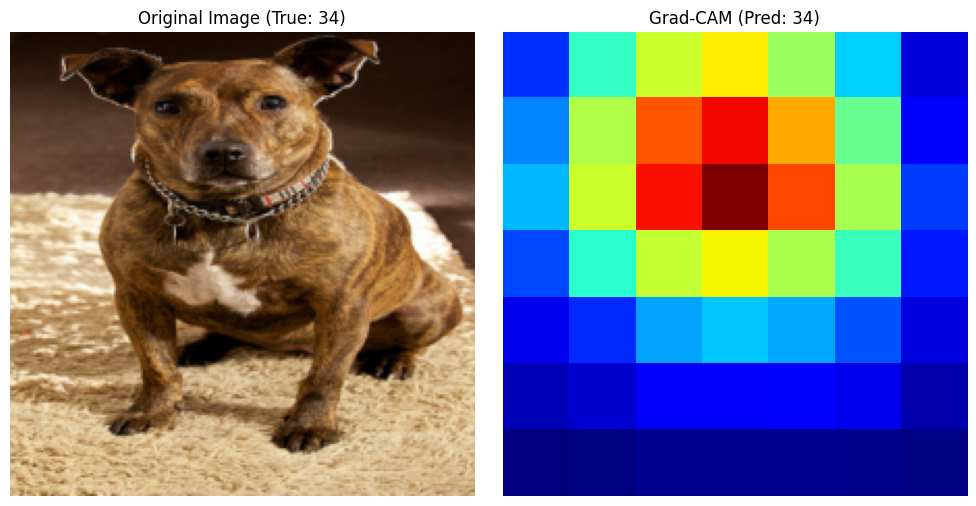

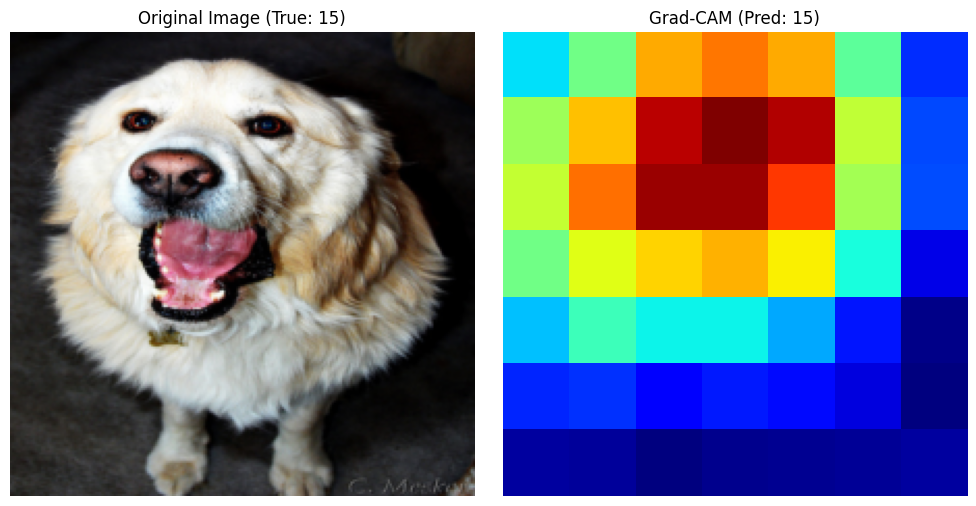

In [14]:
from torchcam.methods import GradCAM
from torchvision.transforms.functional import to_pil_image
import random

model = model.to(device)
cam_extractor = GradCAM(model, target_layer=model.features[7])
model.eval()
indices = random.sample(range(len(test_dataset_transformed)), 5)

for idx in indices:
    image, label = test_dataset_transformed[idx]
    input_tensor = image.unsqueeze(0).to(device)
    scores = model(input_tensor)
    pred = scores.argmax(dim=1).item()
    cam = cam_extractor(pred, scores)[0]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(to_pil_image(image))
    axes[0].set_title(f"Original Image (True: {label})")
    axes[0].axis("off")
    axes[1].imshow(cam.squeeze().cpu(), cmap="jet")
    axes[1].set_title(f"Grad-CAM (Pred: {pred})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

## Task 6 - 4 Marks

Implement a targeted Fast Gradient Sign Method (FGSM) adversarial attack to modify test images originally classified as "American Bulldog" so that they are misclassified as "Pug" by the trained model.
Report the success rate of the attack, which is defined as the fraction of samples that were initially correctly classified as "American Bulldog" but misclassified as "Pug" after the adversarial perturbation.


In [29]:
american_bulldog_idx = test_dataset.classes.index("American Bulldog")
pug_idx = test_dataset.classes.index("Pug")
criterion = torch.nn.CrossEntropyLoss()
epsilon = 0.03
model.eval()
successful_attacks = 0
total_attempts = 0
attack_model = CustomResNet18(num_classes=num_classes).to(device)
attack_model.load_state_dict(model.state_dict())
attack_model.eval()

for imgs, lbls in test_dataloader:
    imgs = imgs.to(device)
    lbls = lbls.to(device)
    with torch.no_grad():
        logits = attack_model(imgs)
        preds = logits.argmax(dim=1)

    valid_mask = (lbls == american_bulldog_idx) & (preds == american_bulldog_idx)
    if valid_mask.sum().item() == 0:continue

    clean_imgs = imgs[valid_mask].clone().detach()
    total_attempts += clean_imgs.size(0)
    clean_imgs.requires_grad = True

    target_lbls = torch.full(
        (clean_imgs.size(0),),
        pug_idx,
        device=device,
        dtype=torch.long
    )
    out = attack_model(clean_imgs)
    loss = criterion(out, target_lbls)

    attack_model.zero_grad()
    loss.backward()
    grad_sign = clean_imgs.grad.sign()
    adv_imgs = clean_imgs - epsilon * grad_sign
    adv_imgs = torch.clamp(adv_imgs, 0, 1)

    with torch.no_grad():
        adv_out = attack_model(adv_imgs)
        adv_preds = adv_out.argmax(dim=1)

    successful_attacks += (adv_preds == pug_idx).sum().item()

del attack_model

success_rate = successful_attacks / total_attempts if total_attempts > 0 else 0
print("Targeted FGSM Attack Success Rate:", round(success_rate, 4))

Targeted FGSM Attack Success Rate: 0.7093
